In [9]:
# standard imports
import pandas as pd
import polars as pl
import numpy as np
import polars.selectors as cs
import umap

# stats imports
from scipy import stats
from scipy.stats import zscore

# plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

# for saving data
import pickle

In [10]:
# load merged tableau

with open('../data/processed/tableau.pkl', 'rb') as f:
    saved = pickle.load(f)

data = saved['data']  # pandas DataFrame, all PRCDDA rows, leakage removed


In [11]:
# 2a) i) Load and merge — report dimensions
display(data.head())
print(f"Merged data shape: {data.shape[0]} rows x {data.shape[1]} columns")
print(f"(includes HBR target column)")

,HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,...,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
0,227,2.880240e+06,1.329181e+06,711659.516933,2.389874e+06,668630.235525,448684.510062,1.122853e+06,45068.095948,1.353868e+06,...,41,26,445,512,512,60,452,0,0,0
1,148,1.963303e+06,9.178011e+05,462765.977777,1.621134e+06,492538.611137,293616.580828,7.442826e+05,38154.948342,1.112284e+06,...,70,18,266,354,354,53,301,0,0,0
2,217,2.764173e+06,1.258474e+06,630450.468070,2.101300e+06,760045.201358,413603.393883,9.979530e+05,60993.430883,1.259138e+06,...,57,22,398,477,425,52,373,52,5,47
3,256,3.192168e+06,1.456848e+06,743198.496523,2.569720e+06,844515.876136,483194.397362,1.168927e+06,62657.604077,1.514437e+06,...,81,37,462,580,537,69,468,43,4,39
4,132,1.655499e+06,7.353739e+05,379035.223330,1.325561e+06,417936.024354,254789.356044,6.042881e+05,27130.858043,7.123371e+05,...,22,13,291,326,326,48,278,0,0,0


Merged data shape: 56857 rows x 1125 columns
(includes HBR target column)


In [12]:
# 2a) iv) Train-test split (80/20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=['HBR']),
    data['HBR'],
    test_size=0.2,
    random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (45485, 1124), X_test: (11372, 1124)
y_train: (45485,), y_test: (11372,)


In [13]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

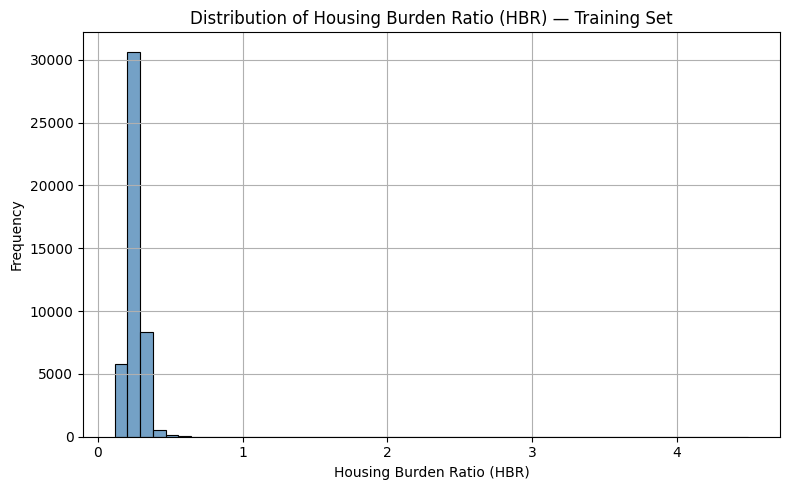

Mean:     0.2570
Median:   0.2513
Std:      0.0585
Skewness: 15.4075


In [14]:
# 2a) v) Distribution of y

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_train, bins=50, edgecolor="black", alpha=0.75, color="steelblue", ax=ax)
ax.set_title("Distribution of Housing Burden Ratio (HBR) — Training Set")
ax.set_xlabel("Housing Burden Ratio (HBR)")
ax.set_ylabel("Frequency")
ax.grid(True)
plt.tight_layout()
plt.show()

skewness = stats.skew(y_train)
print(f"Mean:     {y_train.mean():.4f}")
print(f"Median:   {y_train.median():.4f}")
print(f"Std:      {y_train.std():.4f}")
print(f"Skewness: {skewness:.4f}")


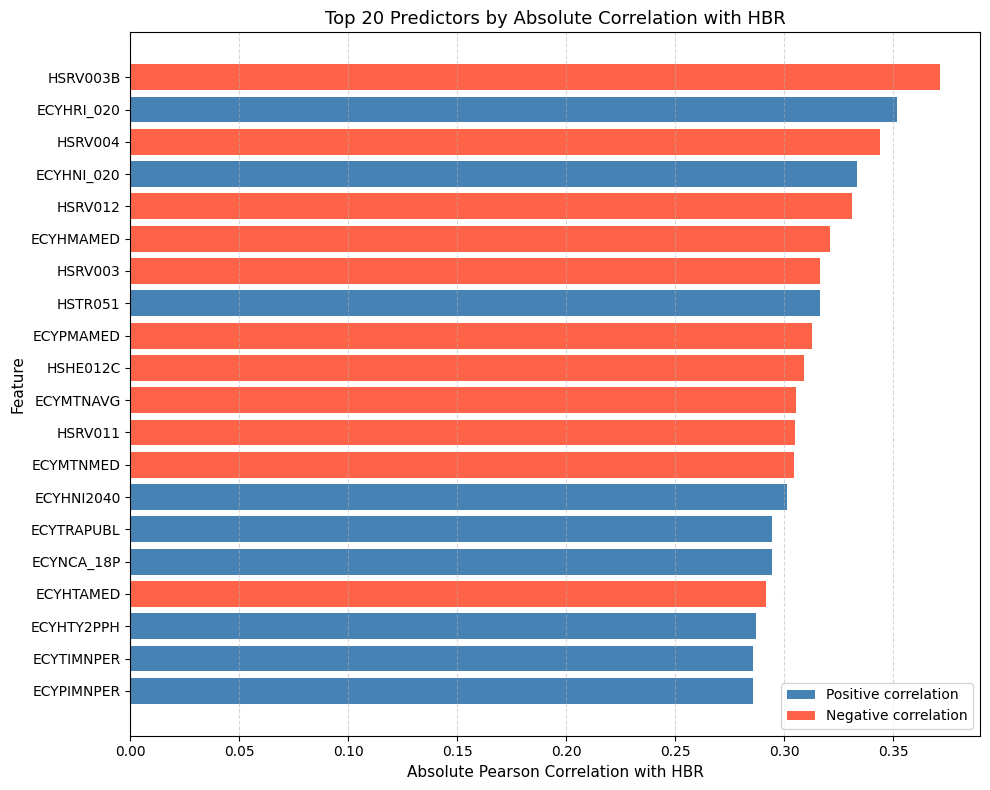

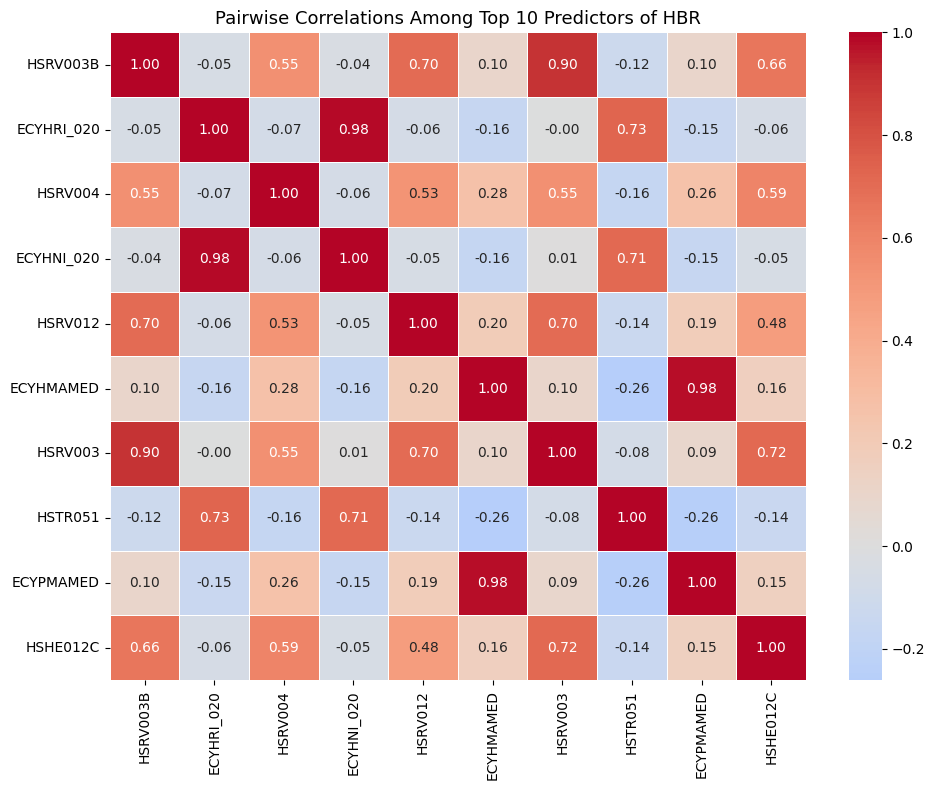

Top 20 correlations (signed):
  HSRV003B: -0.3713
  ECYHRI_020: 0.3518
  HSRV004: -0.3440
  ECYHNI_020: 0.3334
  HSRV012: -0.3309
  ECYHMAMED: -0.3210
  HSRV003: -0.3166
  HSTR051: 0.3166
  ECYPMAMED: -0.3126
  HSHE012C: -0.3092
  ECYMTNAVG: -0.3053
  HSRV011: -0.3050
  ECYMTNMED: -0.3045
  ECYHNI2040: 0.3015
  ECYTRAPUBL: 0.2944
  ECYNCA_18P: 0.2944
  ECYHTAMED: -0.2916
  ECYHTY2PPH: 0.2872
  ECYTIMNPER: 0.2858
  ECYPIMNPER: 0.2858


In [15]:
# 2a) vi) correlation
correlations = X_train.corrwith(y_train).dropna()
top_20_abs = correlations.abs().sort_values(ascending=False).head(20)
top_20_signed = correlations.loc[top_20_abs.index]

# Bar chart of absolute correlations, coloured by sign
colors = ["steelblue" if top_20_signed[f] > 0 else "tomato" for f in top_20_abs.index]
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_20_abs.index[::-1],
    top_20_abs.values[::-1],
    color=colors[::-1]
)
ax.set_title("Top 20 Predictors by Absolute Correlation with HBR", fontsize=13)
ax.set_xlabel("Absolute Pearson Correlation with HBR", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

legend_elements = [Patch(facecolor="steelblue", label="Positive correlation"),
                   Patch(facecolor="tomato",    label="Negative correlation")]
ax.legend(handles=legend_elements, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Additional visualisation: correlation heatmap of the top 10 features
# This reveals multicollinearity structure among the strongest predictors
top_10_features = top_20_abs.index[:10].tolist()
corr_matrix = X_train[top_10_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Pairwise Correlations Among Top 10 Predictors of HBR", fontsize=13)
plt.tight_layout()
plt.show()

# Print signed correlation values
print("Top 20 correlations (signed):")
for feature in top_20_abs.index:
    print(f"  {feature}: {correlations[feature]:.4f}")


In [25]:
# 2b) i) KMeans for k = 2,...,12

inertias = []
silhouette_scores_list = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores_list.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:>14.1f}  silhouette={sil:.4f}")

k= 2  inertia=    38480999.7  silhouette=0.7765
k= 3  inertia=    32687896.5  silhouette=0.5392
k= 4  inertia=    30307733.1  silhouette=0.3997
k= 5  inertia=    28876872.1  silhouette=0.2644
k= 6  inertia=    27924032.7  silhouette=0.1760
k= 7  inertia=    27338074.1  silhouette=0.0798
k= 8  inertia=    26810994.8  silhouette=0.0822
k= 9  inertia=    26197965.5  silhouette=0.0940
k=10  inertia=    25823387.7  silhouette=0.1108
k=11  inertia=    25383279.6  silhouette=0.0477
k=12  inertia=    25058384.1  silhouette=0.0223


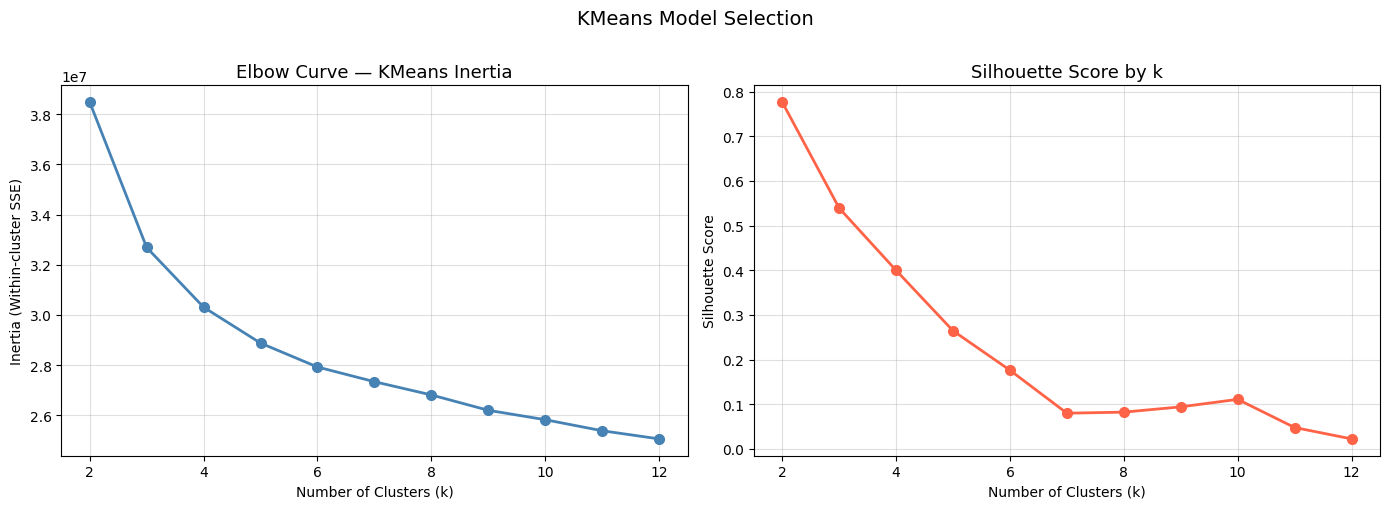

Best k by silhouette score: k=2  (score=0.7765)


In [26]:
# 2b) ii) Elbow curve and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow curve ---
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title("Elbow Curve — KMeans Inertia", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].grid(True, alpha=0.4)

# --- Silhouette scores ---
axes[1].plot(list(k_range), silhouette_scores_list, 'o-', color='tomato', linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score by k", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)

plt.suptitle("KMeans Model Selection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[silhouette_scores_list.index(max(silhouette_scores_list))]
print(f"Best k by silhouette score: k={best_k_sil}  (score={max(silhouette_scores_list):.4f})")

Cluster sizes:
cluster_name
High-Spending Immigrants      233
Low-Spending Canadians      40895
Mid-Income                   4357

Cluster means on interpretable variables:
Cluster                          High-Spending Immigrants  Low-Spending Canadians  Mid-Income
Phone expenditure ($)                           5562920.3                478492.5   1471465.3
Food expenditure ($)                           33300182.1               2850904.2   8886321.8
Transportation expenditure ($)                 34091340.8               2873486.7   8773146.1
Health care expenditure ($)                     7809996.4                735371.7   2266634.2
Personal care expenditure ($)                   5297407.3                435744.8   1415311.8
Total population (DA)                              7168.8                   568.5      1748.2
Canadian-born citizens                             5640.6                   512.0      1476.2
1st-generation immigrants                          3807.7                  

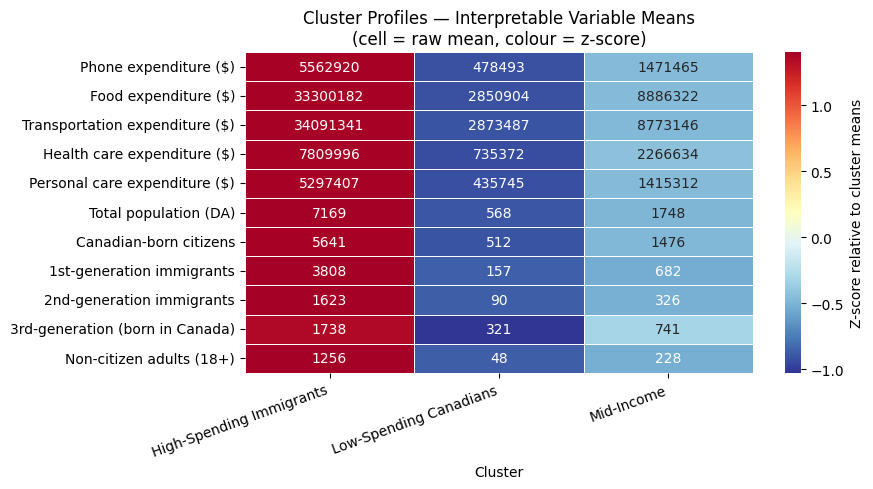


Cluster names:
  High-Spending Immigrants  (n=233)
  Low-Spending Canadians  (n=40895)
  Mid-Income  (n=4357)


In [27]:
# 2b) iv) Cluster sizes and interpretable feature means

OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_train_scaled)

# Attach labels back to original (unscaled) training data for interpretability
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels

# Map numeric labels to descriptive names
cluster_name_map = {0: 'Low-Spending Canadians', 1: 'Mid-Income', 2: 'High-Spending Immigrants'}
X_train_clustered['cluster_name'] = X_train_clustered['cluster'].map(cluster_name_map)

# --- Cluster sizes ---
sizes = X_train_clustered['cluster_name'].value_counts().sort_index()
print("Cluster sizes:")
print(sizes.to_string())
print()

# --- Interpretable variables to compare ---
candidates = {
    'HSCS003':    'Phone expenditure ($)',
    'HSFD001S':   'Food expenditure ($)',
    'HSTR001S':   'Transportation expenditure ($)',
    'HSHC001S':   'Health care expenditure ($)',
    'HSPC001S':   'Personal care expenditure ($)',
    'ECYTCAHPOP': 'Total population (DA)',
    'ECYTCACIT':  'Canadian-born citizens',
    'ECYGEN1GEN': '1st-generation immigrants',
    'ECYGEN2GEN': '2nd-generation immigrants',
    'ECYGEN3GEN': '3rd-generation (born in Canada)',
    'ECYNCA_18P': 'Non-citizen adults (18+)',
}
available = {col: lbl for col, lbl in candidates.items() if col in X_train_clustered.columns}
interp_cols = list(available.keys())

cluster_means = X_train_clustered.groupby('cluster_name')[interp_cols].mean()
cluster_means.index.name = 'Cluster'
cluster_means.columns = [available[c] for c in interp_cols]
print("Cluster means on interpretable variables:")
print(cluster_means.round(1).T.to_string())

# --- Heatmap of cluster means (z-scored for comparability) ---
cluster_means_z = cluster_means.apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    cluster_means_z.T,
    annot=cluster_means.T.round(0).astype(int),
    fmt='d',
    cmap='RdYlBu_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Z-score relative to cluster means'}
)
ax.set_title("Cluster Profiles — Interpretable Variable Means\n(cell = raw mean, colour = z-score)", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nCluster names:")
for name, count in sizes.items():
    print(f"  {name}  (n={count})")

In [28]:
# Save data to pickle for supvervised learning section

X_train_scaled_temp = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_temp = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled_temp["Cluster"] = cluster_labels

with open('../data/processed/kmeans.pkl', 'wb') as f:
    pickle.dump({'X_train_clustered': X_train_clustered,
                 'X_train_scaled': X_train_scaled_temp,
                 'X_test_scaled': X_test_scaled_temp,
                 'X_test': X_test,
                 'y_train': y_train,
                 'y_test': y_test,
                 'K_means_labels': cluster_labels}, f)

print(f"Saved {X_train_clustered.shape[0]} rows x {X_train_clustered.shape[1]} columns to kmeans.pkl")

Saved 45485 rows x 1126 columns to kmeans.pkl


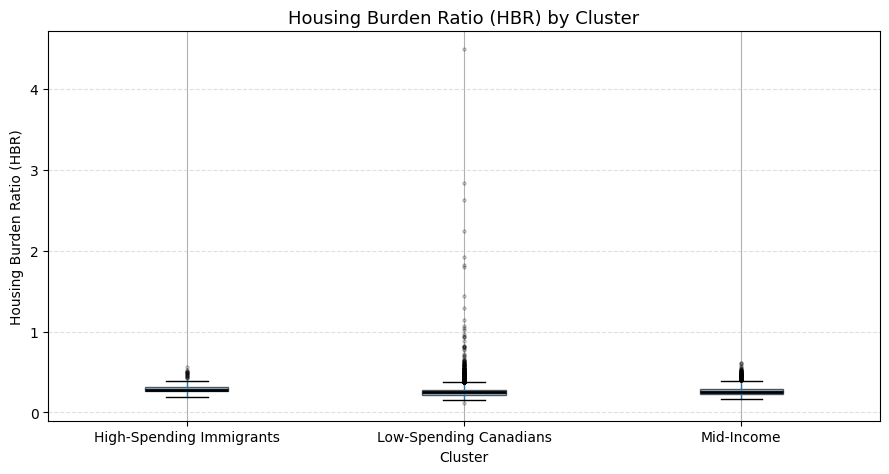

HBR summary by cluster:
                            count    mean     std     min     25%     50%     75%     max
Cluster                                                                                  
High-Spending Immigrants    233.0  0.2978  0.0652  0.1922  0.2600  0.2822  0.3177  0.5584
Low-Spending Canadians    40895.0  0.2557  0.0586  0.1169  0.2212  0.2503  0.2816  4.4942
Mid-Income                 4357.0  0.2671  0.0555  0.1624  0.2290  0.2588  0.2957  0.6128


In [29]:
# 2b) v) Boxplot of target variable y by cluster

y_cluster_df = pd.DataFrame({
    'HBR': y_train.values,
    'Cluster': [cluster_name_map[c] for c in cluster_labels]
})

fig, ax = plt.subplots(figsize=(9, 5))

y_cluster_df.boxplot(
    column='HBR',
    by='Cluster',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey'),
    notch=False,
)

ax.set_title("Housing Burden Ratio (HBR) by Cluster", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Housing Burden Ratio (HBR)")
plt.suptitle("")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("HBR summary by cluster:")
print(y_cluster_df.groupby('Cluster')['HBR'].describe().round(4).to_string())


PC  | Variance Explained | Cumulative Variance
----|-------------------|--------------------
PC 1 | 0.4955 (49.55%)      | 0.4955 (49.55%)
PC 2 | 0.0544 (5.44%)      | 0.5500 (55.00%)
PC 3 | 0.0366 (3.66%)      | 0.5865 (58.65%)
PC 4 | 0.0275 (2.75%)      | 0.6140 (61.40%)
PC 5 | 0.0258 (2.58%)      | 0.6398 (63.98%)
PC 6 | 0.0164 (1.64%)      | 0.6563 (65.63%)
PC 7 | 0.0137 (1.37%)      | 0.6699 (66.99%)
PC 8 | 0.0124 (1.24%)      | 0.6823 (68.23%)
PC 9 | 0.0111 (1.11%)      | 0.6935 (69.35%)
PC10 | 0.0091 (0.91%)      | 0.7025 (70.25%)


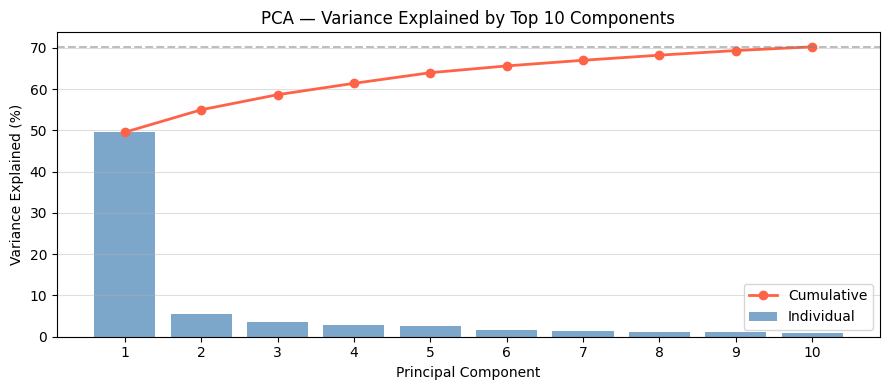

In [30]:
# 2c) i) PCA — cumulative variance explained by top 10 components

pca_model = PCA(n_components=10)
X_pca = pca_model.fit_transform(X_train_scaled)

top10_var = pca_model.explained_variance_ratio_
cumulative_var = np.cumsum(top10_var)

print("PC  | Variance Explained | Cumulative Variance")
print("----|-------------------|--------------------")
for i, (v, cv) in enumerate(zip(top10_var, cumulative_var), 1):
    print(f"PC{i:2d} | {v:.4f} ({v*100:.2f}%)      | {cv:.4f} ({cv*100:.2f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), top10_var * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, 11), cumulative_var * 100, 'o-', color='tomato', linewidth=2, markersize=6, label='Cumulative')
ax.axhline(y=cumulative_var[9]*100, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("PCA — Variance Explained by Top 10 Components")
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

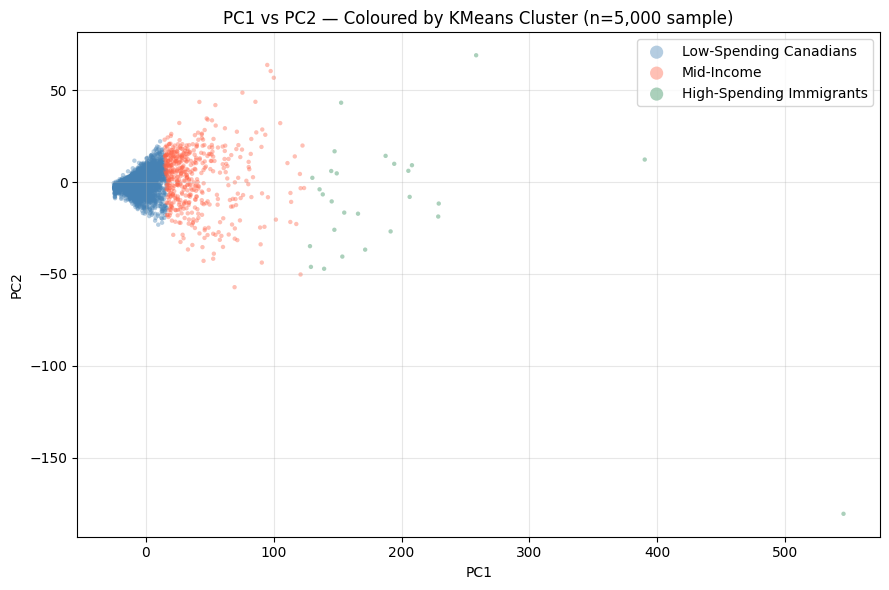

In [31]:
# 2c) ii) PC1 vs PC2 scatter plot coloured by KMeans cluster labels

colors = {0: 'steelblue', 1: 'tomato', 2: 'seagreen'}

# Sample for readability (45k points is too dense to read)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, name in cluster_name_map.items():
    mask = cluster_labels[sample_idx] == cluster_id
    ax.scatter(
        X_pca[sample_idx][mask, 0],
        X_pca[sample_idx][mask, 1],
        c=colors[cluster_id],
        label=name,
        alpha=0.4,
        s=10,
        edgecolors='none'
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PC1 vs PC2 — Coloured by KMeans Cluster (n=5,000 sample)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


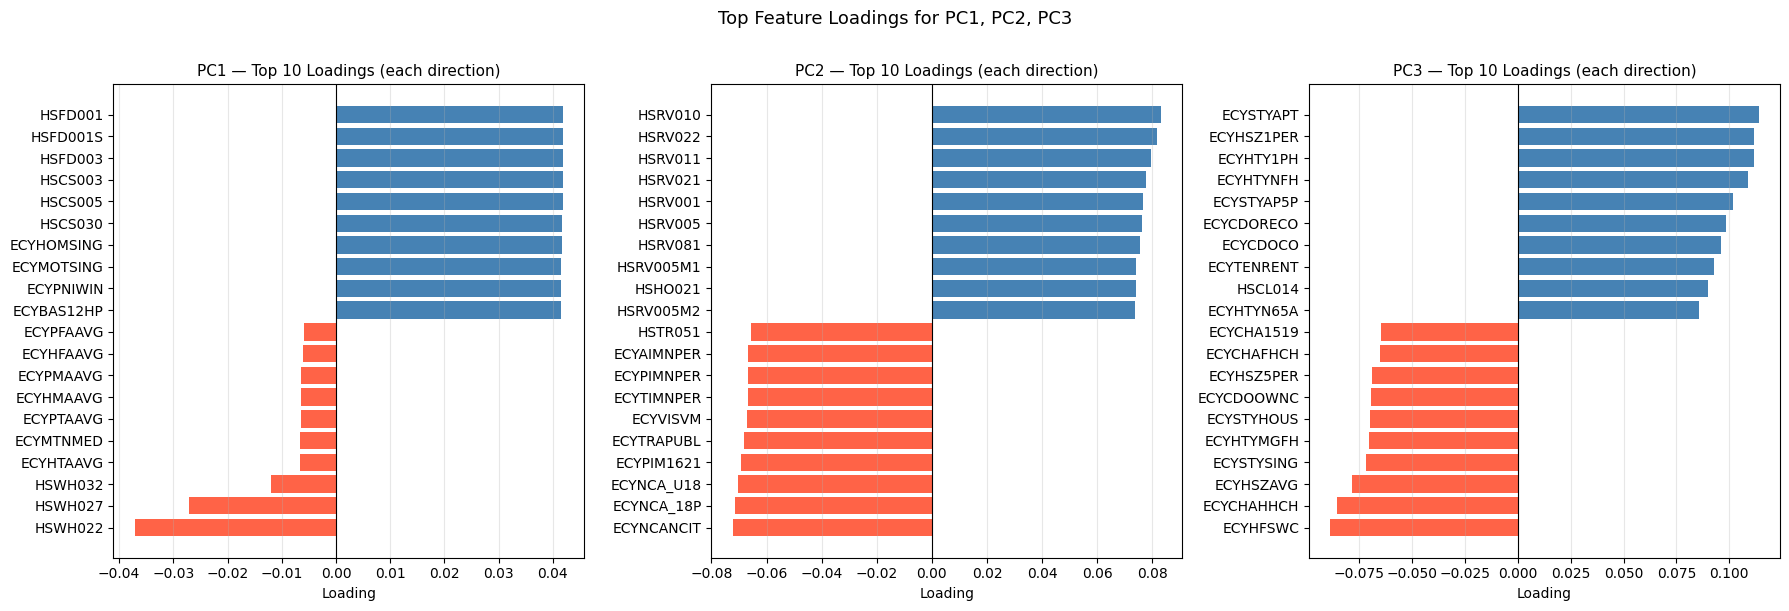


PC1 top loadings:
  HSFD001S              +0.0419
  HSFD001               +0.0419
  HSFD003               +0.0418
  HSCS003               +0.0418
  HSCS005               +0.0418
  ECYMTNMED             -0.0066
  ECYHTAAVG             -0.0067
  HSWH032               -0.0120
  HSWH027               -0.0270
  HSWH022               -0.0371

PC2 top loadings:
  HSRV010               +0.0830
  HSRV022               +0.0817
  HSRV011               +0.0795
  HSRV021               +0.0776
  HSRV001               +0.0764
  ECYTRAPUBL            -0.0681
  ECYPIM1621            -0.0694
  ECYNCA_U18            -0.0703
  ECYNCA_18P            -0.0713
  ECYNCANCIT            -0.0723

PC3 top loadings:
  ECYSTYAPT             +0.1139
  ECYHSZ1PER            +0.1117
  ECYHTY1PH             +0.1116
  ECYHTYNFH             +0.1088
  ECYSTYAP5P            +0.1017
  ECYHTYMGFH            -0.0703
  ECYSTYSING            -0.0717
  ECYHSZAVG             -0.0784
  ECYCHAHHCH            -0.0855
  ECYHFSWC     

In [32]:
# 2c) iii) Top-loading features for PC1, PC2, PC3

# X_train_scaled is a NumPy array, so use original DataFrame columns
feature_names = X_train.columns.tolist()
N_TOP = 10  # top loadings to display per PC

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for pc_idx in range(3):
    loadings = pd.Series(pca_model.components_[pc_idx], index=feature_names)
    top_pos = loadings.nlargest(N_TOP)
    top_neg = loadings.nsmallest(N_TOP)
    top = pd.concat([top_neg, top_pos]).sort_values()

    colors_bar = ['tomato' if v < 0 else 'steelblue' for v in top.values]
    axes[pc_idx].barh(top.index, top.values, color=colors_bar)
    axes[pc_idx].axvline(0, color='black', linewidth=0.8)
    axes[pc_idx].set_title(f"PC{pc_idx+1} — Top {N_TOP} Loadings (each direction)", fontsize=11)
    axes[pc_idx].set_xlabel("Loading")
    axes[pc_idx].grid(axis='x', alpha=0.3)

plt.suptitle("Top Feature Loadings for PC1, PC2, PC3", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print numeric values
for pc_idx in range(3):
    loadings = pd.Series(pca_model.components_[pc_idx], index=feature_names)
    top = pd.concat([loadings.nlargest(5), loadings.nsmallest(5)]).sort_values(ascending=False)
    print(f"\nPC{pc_idx+1} top loadings:")
    for feat, val in top.items():
        print(f"  {feat:20s}  {val:+.4f}")

Mean PC scores by cluster:
                              PC1    PC2    PC3
cluster_name                                   
High-Spending Immigrants  219.298 -9.460 -3.031
Low-Spending Canadians     -5.195 -0.278 -0.202
Mid-Income                 37.032  3.115  2.058


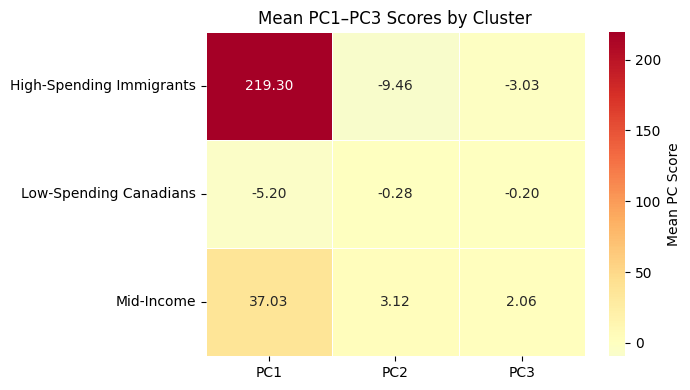

In [33]:
# 2c) iv) Mean PC scores by cluster (PC1–PC3)

pc_scores = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pc_scores['cluster'] = cluster_labels
pc_scores['cluster_name'] = pc_scores['cluster'].map(cluster_name_map)

mean_scores = pc_scores.groupby('cluster_name')[['PC1', 'PC2', 'PC3']].mean().round(3)
print("Mean PC scores by cluster:")
print(mean_scores.to_string())

# Heatmap of mean PC scores
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    mean_scores,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Mean PC Score'}
)
ax.set_title("Mean PC1–PC3 Scores by Cluster", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [34]:
# 2d) i) UMAP -- parameter search then final fit

# Parameter search on an 8k subsample to keep runtime reasonable
np.random.seed(42)
search_idx = np.random.choice(len(X_train_scaled), size=8000, replace=False)
X_search = X_train_scaled[search_idx]
labels_search = cluster_labels[search_idx]

n_neighbors_grid = [5, 15, 30, 50]
min_dist_grid    = [0.0, 0.1, 0.25]

print(f"{'n_neighbors':>12} {'min_dist':>10} {'silhouette':>12}")
print("-" * 38)

best_score, best_nn, best_md = -1, None, None
results = []

for nn in n_neighbors_grid:
    for md in min_dist_grid:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md,
                            random_state=42, n_jobs=1)
        emb = reducer.fit_transform(X_search)
        sil = silhouette_score(emb, labels_search)
        results.append((nn, md, sil))
        print(f"{nn:>12} {md:>10.2f} {sil:>12.4f}")
        if sil > best_score:
            best_score, best_nn, best_md = sil, nn, md

print(f"\nBest params: n_neighbors={best_nn}, min_dist={best_md}  (silhouette={best_score:.4f})")

# Fit final UMAP on full training set with best params
print("\nFitting final UMAP on full training set...")
umap_final = umap.UMAP(n_components=2, n_neighbors=best_nn, min_dist=best_md,
                        random_state=42, n_jobs=1)
X_umap = umap_final.fit_transform(X_train_scaled)
print(f"UMAP embedding shape: {X_umap.shape}")

 n_neighbors   min_dist   silhouette
--------------------------------------
           5       0.00      -0.0285
           5       0.10       0.0348
           5       0.25       0.0814
          15       0.00       0.0447
          15       0.10       0.1087
          15       0.25       0.1563
          30       0.00       0.0965
          30       0.10       0.1306
          30       0.25       0.1627
          50       0.00       0.1305


KeyboardInterrupt: 

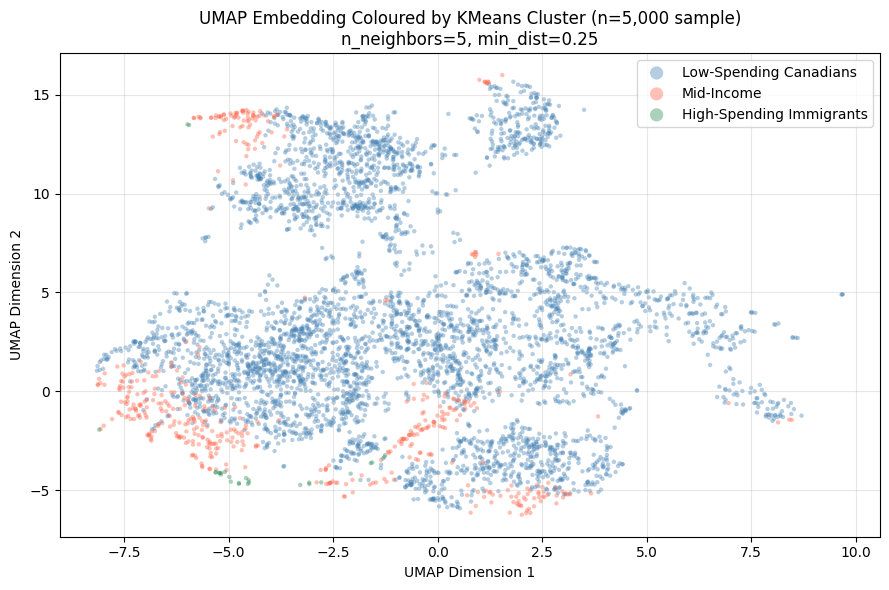

In [18]:
# 2d) ii) UMAP scatter plot coloured by KMeans cluster labels

# Sample for plot readability
np.random.seed(42)
plot_idx = np.random.choice(len(X_umap), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cid, name in cluster_name_map.items():
    mask = cluster_labels[plot_idx] == cid
    ax.scatter(
        X_umap[plot_idx][mask, 0],
        X_umap[plot_idx][mask, 1],
        c=colors[cid], label=name, alpha=0.4, s=10, edgecolors='none'
    )

ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'UMAP Embedding Coloured by KMeans Cluster (n=5,000 sample)\n'
             f'n_neighbors={best_nn}, min_dist={best_md}')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Silhouette score in original high-dim space (k=3): 0.5410
Silhouette score in 2-dim UMAP space       (k=3): 0.0589


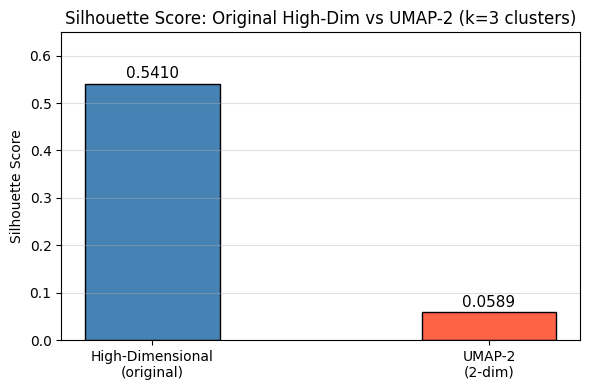


Per-cluster mean silhouette (High-Dim vs UMAP-2):
  Cluster                      High-Dim     UMAP-2
  Low-Spending Canadians         0.6103     0.0871
  Mid-Income                    -0.0797    -0.2300
  High-Spending Immigrants       0.0167     0.4617


In [19]:
# 2d) iii) Silhouette score in 2D UMAP space vs original high-dimensional space

# Subsample for silhouette (full 45k is slow)
np.random.seed(42)
sil_idx = np.random.choice(len(X_umap), size=10000, replace=False)

sil_umap = silhouette_score(X_umap[sil_idx],        cluster_labels[sil_idx])
sil_hd   = silhouette_score(X_train_scaled[sil_idx], cluster_labels[sil_idx])

print(f'Silhouette score in original high-dim space (k=3): {sil_hd:.4f}')
print(f'Silhouette score in 2-dim UMAP space       (k=3): {sil_umap:.4f}')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['High-Dimensional\n(original)', 'UMAP-2\n(2-dim)'],
              [sil_hd, sil_umap],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='black')
for bar, val in zip(bars, [sil_hd, sil_umap]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, max(sil_hd, sil_umap) * 1.2)
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score: Original High-Dim vs UMAP-2 (k=3 clusters)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Per-cluster silhouette samples
sil_vals_umap = silhouette_samples(X_umap[sil_idx],        cluster_labels[sil_idx])
sil_vals_hd   = silhouette_samples(X_train_scaled[sil_idx], cluster_labels[sil_idx])

print('\nPer-cluster mean silhouette (High-Dim vs UMAP-2):')
print('  {:<26} {:>10} {:>10}'.format('Cluster', 'High-Dim', 'UMAP-2'))
for cid, name in cluster_name_map.items():
    mask = cluster_labels[sil_idx] == cid
    print(f'  {name:<26} {sil_vals_hd[mask].mean():>10.4f} {sil_vals_umap[mask].mean():>10.4f}')